In [63]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import solve
from numpy.polynomial.legendre import leggauss
import torch
from scipy.linalg import eigh
from scipy.linalg import solve

!git clone https://github.com/Philipp3011/Parareal-OCP-Convergence-tests-bachelor-thesis.git
%cd Parareal-OCP-Convergence-tests-bachelor-thesis

from parareal_grundfunktionen import *
from propagators import FP, BE, SDIRK22


def parareal_error_for_plot(CP_method, FP_method, J, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine=None, K=25):

    delta_T = (t_end - t_0) / int(N / J)

    U_fine = U_fine_full[::J]

    P_i_sum_CP, R_T_A_h_CP = prepare_CP(delta_T, A_h, CP_method["P"], CP_method["R"])

    if RHS_values_fine is None:
        RHS_values_CP = None
    else:
        RHS_values_CP = prepare_rhs(CP_method["C"], f, mass, delta_T, T_intervall, M, OMEGA)

    _, error = parareal_fehlervergleich(RHS_values_CP, RHS_values_fine, R_T_A_h_CP, R_T_A_h_fine,
                                        P_i_sum_CP, P_i_sum_fine, CP, T_intervall, U_fine, M, N, J, u_0, f,
                                        CP_method["R"], FP_method["R"], CP_method["P"], FP_method["P"],
                                        CP_method["C"], FP_method["C"], K, A_h, stiff, mass, v_h)
    return error


Cloning into 'Parareal-OCP-Convergence-tests-bachelor-thesis'...
remote: Enumerating objects: 221, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 221 (delta 15), reused 2 (delta 2), pack-reused 196 (from 2)
Receiving objects: 100% (221/221), 360.03 KiB | 1.50 MiB/s, done.
Resolving deltas: 100% (132/132), done.
/content/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis

a = [ 1.         -0.17949873]
b = [1.         0.82050127 0.42437056]
best_gamma = 0.016262630000710487


/tmp/ipykernel_5042/2542616056.py:62: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("Quotient_OCP_BE.pdf", bbox_inches="tight")
/tmp/ipykernel_5042/2542616056.py:62: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("Quotient_OCP_BE.pdf", bbox_inches="tight")
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


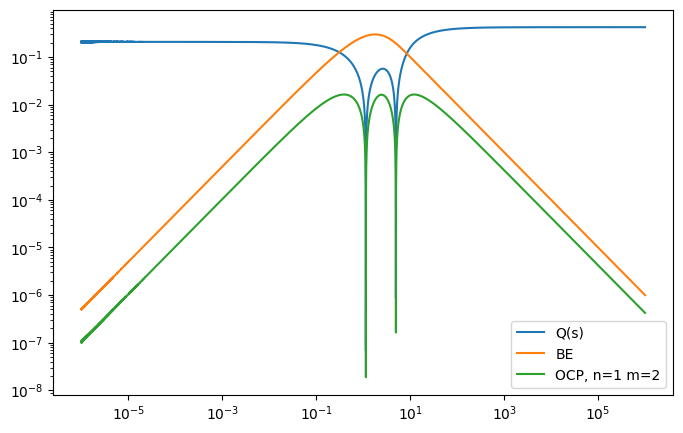

In [64]:
#Figure 4.5

import numpy as np
import torch
import matplotlib.pyplot as plt

saved2_n1m2_001_100 = torch.load(
    "models/n1m2_001_100_LOBATTOIIIC4_J20.pt",
    map_location="cpu",
    weights_only=False
)

if isinstance(saved2_n1m2_001_100, list):
    result2 = saved2_n1m2_001_100[0]
else:
    result2 = saved2_n1m2_001_100

a_opt2_n1m2_001_100= result2["a"].detach().cpu().numpy().astype(np.float64)
b_opt2_n1m2_001_100= result2["b"].detach().cpu().numpy().astype(np.float64)

print("a =", a_opt2_n1m2_001_100)
print("b =", b_opt2_n1m2_001_100)
print("best_gamma =", result2["best_gamma"])

def R_opt2_n1m2_001_100(x):
    numerator = np.polynomial.polynomial.polyval(x, a_opt2_n1m2_001_100)
    denominator = np.polynomial.polynomial.polyval(x, b_opt2_n1m2_001_100)
    return numerator / denominator


def R_BE(x):
  return 1/(1+x)

def r4(x):
    return (12*x**2 - 120*x + 360) / (
        x**4 + 12*x**3 + 72*x**2 + 240*x + 360
    )

J = 20
s = np.logspace(-6,6,1000000)
fine_value = np.abs(r4(s/J)**J)

R_opt2 = R_opt2_n1m2_001_100(s)
R_be = R_BE(s)

kappa_BE = np.abs(fine_value - R_be) / (1- np.abs(R_be))
kappa_opt2 = np.abs(fine_value - R_opt2) / (1- np.abs(R_opt2))

def efficiency_quotient2_func(x):
  return (np.abs(r4(x/J)**J - R_opt2_n1m2_001_100(x)) / (1- np.abs(R_opt2_n1m2_001_100(x))) )/(np.abs(r4(x/J)**J - R_BE(x)) / (1- np.abs(R_BE(x)))
)

efficiency_quotient2_arr = kappa_opt2 / kappa_BE
plt.figure(figsize = (8,5))
plt.plot(s, efficiency_quotient2_arr, label = "Q(s)")
plt.plot(s, kappa_BE, label = "BE")
plt.plot(s, kappa_opt2, label = "OCP, n=1 m=2")

plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.savefig("Quotient_OCP_BE.pdf", bbox_inches="tight")
plt.savefig("Quotient_OCP_BE.png", dpi=300, bbox_inches="tight")
plt.show()

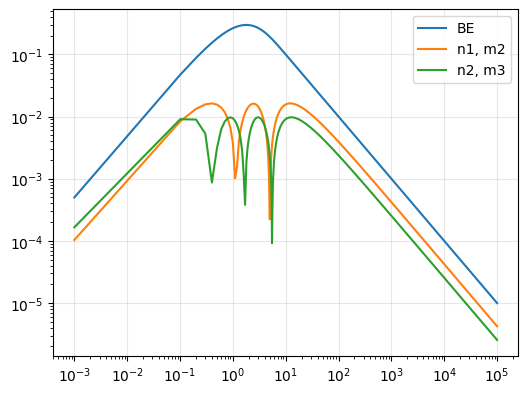

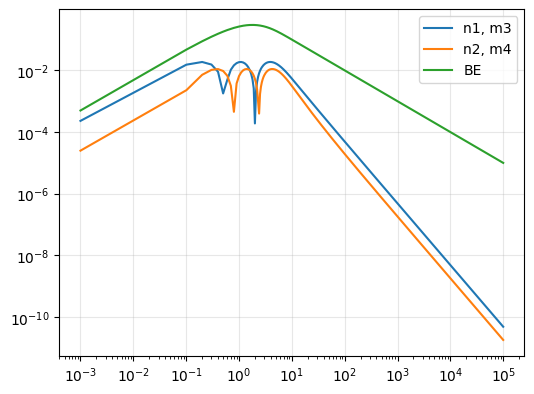

In [65]:
#Figure 4.4

import torch
import numpy as np
import matplotlib.pyplot as plt

saved_n1m2 = torch.load("models/n1m2_001_100_LOBATTOIIIC4_J20.pt",map_location="cpu",weights_only=False)
saved_n1m3 = torch.load("models/n1m3_001_100_LOBATTOIIIC4_J20.pt",map_location="cpu",weights_only=False)
saved_n2m3 = torch.load("models/n2m3_001_100_LOBATTOIIIC4_J20.pt",map_location="cpu",weights_only=False)
saved_n2m4 = torch.load("models/n2m4_001_100_LOBATTOIIIC4_J20.pt",map_location="cpu",weights_only=False)
##################################################################
if isinstance(saved_n2m3, list):
    result_n2m3 = saved_n2m3[0]
else:
    result_n2m3 = saved_n2m3

a_n2m3= result_n2m3["a"].detach().cpu().numpy().astype(np.float64)
b_n2m3= result_n2m3["b"].detach().cpu().numpy().astype(np.float64)
##################################################################
if isinstance(saved_n2m4, list):
    result_n2m4 = saved_n2m4[0]
else:
    result_n2m4 = saved_n2m4

a_n2m4= result_n2m4["a"].detach().cpu().numpy().astype(np.float64)
b_n2m4= result_n2m4["b"].detach().cpu().numpy().astype(np.float64)
##################################################################
if isinstance(saved_n1m3, list):
    result_n1m3 = saved_n1m3[0]
else:
    result_n1m3 = saved_n1m3

a_n1m3= result_n1m3["a"].detach().cpu().numpy().astype(np.float64)
b_n1m3= result_n1m3["b"].detach().cpu().numpy().astype(np.float64)
##################################################################
if isinstance(saved_n1m2, list):
    result_n1m2 = saved_n1m2[0]
else:
    result_n1m2 = saved_n1m2

a_n1m2= result_n1m2["a"].detach().cpu().numpy().astype(np.float64)
b_n1m2= result_n1m2["b"].detach().cpu().numpy().astype(np.float64)
##################################################################
def R_opt_n1m3(x):
    numerator = np.polynomial.polynomial.polyval(x, a_n1m3)
    denominator = np.polynomial.polynomial.polyval(x, b_n1m3)
    return numerator / denominator

def R_opt_n2m4(x):
    numerator = np.polynomial.polynomial.polyval(x, a_n2m4)
    denominator = np.polynomial.polynomial.polyval(x, b_n2m4)
    return numerator / denominator

def R_opt_n2m3(x):
    numerator = np.polynomial.polynomial.polyval(x, a_n2m3)
    denominator = np.polynomial.polynomial.polyval(x, b_n2m3)
    return numerator / denominator

def R_opt_n1m2(x):
    numerator = np.polynomial.polynomial.polyval(x, a_n1m2)
    denominator = np.polynomial.polynomial.polyval(x, b_n1m2)
    return numerator / denominator
##################################################################
def R_BE(x):
  return 1/(1+x)

def r4(x):
    return (12*x**2 - 120*x + 360) / (
        x**4 + 12*x**3 + 72*x**2 + 240*x + 360
    )

def R_SDIRK22(x):
    gamma = (2.0 - np.sqrt(2.0)) / 2.0

    return (
        1.0 + (2.0 * gamma - 1.0) * x
    ) / (
        1.0 + gamma * x
    )**2
##################################################################
J = 20
s = np.linspace(0.001,100000,1000000)
fine_value = np.abs(r4(s/J)**J)
SD_fine_value = np.abs(R_SDIRK22(s/J)**J)

R_n1m2 = R_opt_n1m2(s)
R_n1m3 = R_opt_n1m3(s)
R_n2m3 = R_opt_n2m3(s)
R_n2m4 = R_opt_n2m4(s)
R_be = R_BE(s)
R_SDIRK = R_SDIRK22(s)


kappa_BE = np.abs(fine_value - R_be) / (1- np.abs(R_be))
kappa_n1m3 = np.abs(fine_value - R_n1m3) / (1- np.abs(R_n1m3))
kappa_n2m3 = np.abs(fine_value - R_n2m3) / (1- np.abs(R_n2m3))
kappa_n2m4 = np.abs(fine_value - R_n2m4) / (1- np.abs(R_n2m4))
kappa_n1m2 = np.abs(fine_value - R_n1m2) / (1- np.abs(R_n1m2))
kappa_SD = np.abs(SD_fine_value - R_SDIRK) / (1- np.abs(R_SDIRK))
##################################################################
plt.figure(figsize = (6,4.5))

plt.plot(s, kappa_BE, label = "BE")
#plt.plot(s, kappa_n1m3, label = "n1, m3")
plt.plot(s, kappa_n1m2, label = "n1, m2")
plt.plot(s, kappa_n2m3, label = "n2, m3")
#plt.plot(s, kappa_SD, label = "SDIRK-22 as CP,FP")

plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.grid(alpha=0.3)
plt.show

plt.savefig(
    "/content/Konvergenzfaktoren: n1m2,n2m3 vs BE.png",
    dpi=300,
    bbox_inches="tight"
)
##################################################################
plt.figure(figsize=(6,4.5))

plt.plot(s, kappa_n1m3, label = "n1, m3")
plt.plot(s, kappa_n2m4, label = "n2, m4")
plt.plot(s, kappa_BE, label = "BE")

plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.grid(alpha=0.3)
plt.show

plt.savefig(
    "/content/Konvergenzfaktoren: n1m3, n2m4 vs BE.png",
    dpi=300,
    bbox_inches="tight"
)



a = [ 1.         -0.21879441  0.00618607]
b = [1.         0.78120559 0.36814663]
best_gamma = 0.012796558439731598


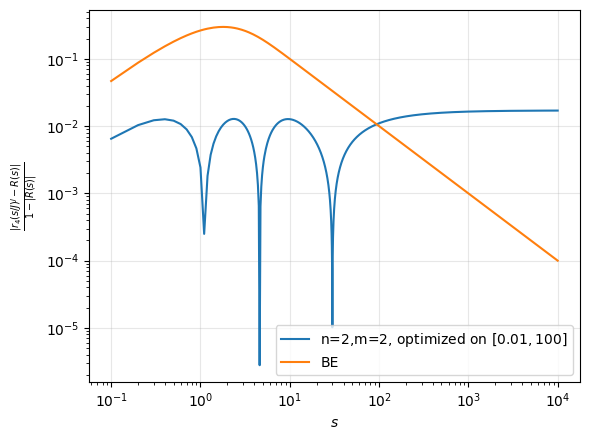

In [66]:
#Figure 4.3

import numpy as np
import matplotlib.pyplot as plt
import torch


saved_n2m2_001_100 = torch.load(
    "models/n2m2_d1_0.01_100.pt",
    map_location="cpu",
    weights_only=False
)

# Falls die Datei eine Liste enthält
if isinstance(saved_n2m2_001_100, list):
    result = saved_n2m2_001_100[0]
else:
    result = saved_n2m2_001_100

a_opt_n2m2_001_100= result["a"].detach().cpu().numpy().astype(np.float64)
b_opt_n2m2_001_100= result["b"].detach().cpu().numpy().astype(np.float64)

print("a =", a_opt_n2m2_001_100)
print("b =", b_opt_n2m2_001_100)
print("best_gamma =", result["best_gamma"])

def R_opt_n2m2_001_100(x):
    numerator = np.polynomial.polynomial.polyval(x, a_opt_n2m2_001_100)
    denominator = np.polynomial.polynomial.polyval(x, b_opt_n2m2_001_100)
    return numerator / denominator



def r4(x):
    return (12*x**2 - 120*x + 360) / (
        x**4 + 12*x**3 + 72*x**2 + 240*x + 360
    )
def R_BE(x):
    return 1.0 / (1.0 + x)



s = np.linspace(0.1, 10000, 100000)

J=20

fine_value = r4(s / J)**J

R_be = R_BE(s)
R_n2m2_001_100 = R_opt_n2m2_001_100(s)


kappa_n2m2_001_100= (
    np.abs(fine_value - R_n2m2_001_100)
    / (1.0 - np.abs(R_n2m2_001_100))
)
kappa_BE= (
    np.abs(fine_value - R_be)
    / (1.0 - np.abs(R_be))
)



plt.figure(figsize=(6, 4.5))



plt.plot(
    s,
    kappa_n2m2_001_100,
    label="n=2,m=2, optimized on $[0.01,100]$"
)
plt.plot(
    s,
    kappa_BE,
    label="BE"
)


plt.yscale("log")
plt.xscale("log")
plt.xlabel(r"$s$")
plt.ylabel(
    r"$\frac{|r_4(s/J)^J-R(s)|}{1-|R(s)|}$"
)

#plt.title(
#    "$\kappa(r,R(\lambda,\theta),J,s)$, optimized on $[0.01,10]\cup\sigma(cA_h)$, c=1,10,100,500,900"
#)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/Konvergenzfaktoren: BE vs n2m2 on 001 bis 100.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

a = [ 1.         -0.20806861  0.00480669]
b = [1.         0.79193139 0.38511071]
best_gamma = 0.013942601159214973
a = [ 1.         -0.21149468  0.00499834]
b = [1.         0.78850532 0.37866864]
best_gamma = 0.013389373198151588
a = [ 1.         -0.21149236  0.00499768]
b = [1.         0.78850764 0.37866956]
best_gamma = 0.013389318250119686
a = [ 1.         -0.21149236  0.00499768]
b = [1.         0.78850764 0.37866956]
best_gamma = 0.013389318250119686
a = [ 1.         -0.21149236  0.00499768]
b = [1.         0.78850764 0.37866956]
best_gamma = 0.013389318250119686
a = [ 1.         -0.21879441  0.00618607]
b = [1.         0.78120559 0.36814663]
best_gamma = 0.012796558439731598


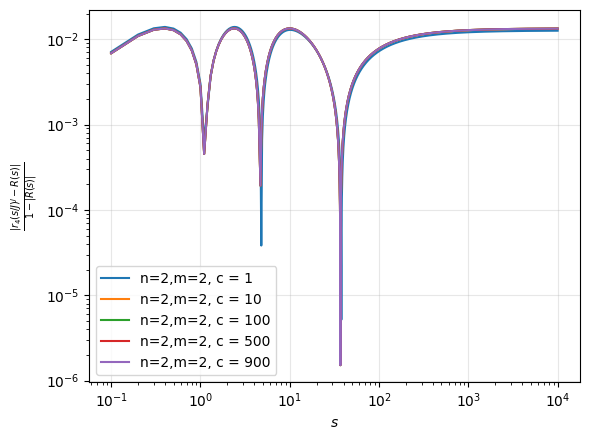

In [67]:
#figure 4.2

import numpy as np
import matplotlib.pyplot as plt
import torch

saved_A_1 = torch.load(
    "models/ocp_result_1_exact_plus_small_range.pt",
    map_location="cpu",
    weights_only=False
)

# Falls die Datei eine Liste enthält
if isinstance(saved_A_1, list):
    result = saved_A_1[0]
else:
    result = saved_A_1

a_opt_A_1= result["a"].detach().cpu().numpy().astype(np.float64)
b_opt_A_1= result["b"].detach().cpu().numpy().astype(np.float64)

print("a =", a_opt_A_1)
print("b =", b_opt_A_1)
print("best_gamma =", result["best_gamma"])

####

saved_A_10 = torch.load(
    "models/ocp_result_10_exact_plus_small_range.pt",
    map_location="cpu",
    weights_only=False
)

# Falls die Datei eine Liste enthält
if isinstance(saved_A_10, list):
    result = saved_A_10[0]
else:
    result = saved_A_10

a_opt_A_10= result["a"].detach().cpu().numpy().astype(np.float64)
b_opt_A_10= result["b"].detach().cpu().numpy().astype(np.float64)

print("a =", a_opt_A_10)
print("b =", b_opt_A_10)
print("best_gamma =", result["best_gamma"])

##########

saved_A_100 = torch.load(
    "models/ocp_result_100_exact_plus_small_range.pt",
    map_location="cpu",
    weights_only=False
)

# Falls die Datei eine Liste enthält
if isinstance(saved_A_100, list):
    result = saved_A_100[0]
else:
    result = saved_A_100

a_opt_A_100= result["a"].detach().cpu().numpy().astype(np.float64)
b_opt_A_100= result["b"].detach().cpu().numpy().astype(np.float64)

print("a =", a_opt_A_100)
print("b =", b_opt_A_100)
print("best_gamma =", result["best_gamma"])


###########


saved_A_500 = torch.load(
    "models/ocp_result_500_exact_plus_small_range.pt",
    map_location="cpu",
    weights_only=False
)

# Falls die Datei eine Liste enthält
if isinstance(saved_A_500, list):
    result = saved_A_500[0]
else:
    result = saved_A_500

a_opt_A_500= result["a"].detach().cpu().numpy().astype(np.float64)
b_opt_A_500= result["b"].detach().cpu().numpy().astype(np.float64)

print("a =", a_opt_A_500)
print("b =", b_opt_A_500)
print("best_gamma =", result["best_gamma"])


#############

saved_A_900 = torch.load(
    "models/ocp_result_900_exact_plus_small_range.pt",
    map_location="cpu",
    weights_only=False
)

# Falls die Datei eine Liste enthält
if isinstance(saved_A_900, list):
    result = saved_A_900[0]
else:
    result = saved_A_900

a_opt_A_900= result["a"].detach().cpu().numpy().astype(np.float64)
b_opt_A_900= result["b"].detach().cpu().numpy().astype(np.float64)

print("a =", a_opt_A_900)
print("b =", b_opt_A_900)
print("best_gamma =", result["best_gamma"])


###############


saved_n2m2_001_10 = torch.load(
    "models/n2m2_d1_0.01_100.pt",
    map_location="cpu",
    weights_only=False
)

# Falls die Datei eine Liste enthält
if isinstance(saved_n2m2_001_10, list):
    result = saved_n2m2_001_10[0]
else:
    result = saved_n2m2_001_10

a_opt_n2m2_001_10= result["a"].detach().cpu().numpy().astype(np.float64)
b_opt_n2m2_001_10= result["b"].detach().cpu().numpy().astype(np.float64)

print("a =", a_opt_n2m2_001_10)
print("b =", b_opt_n2m2_001_10)
print("best_gamma =", result["best_gamma"])



################# Stability functions ################################
def R_opt_A_1(x):
    numerator = np.polynomial.polynomial.polyval(x, a_opt_A_1)
    denominator = np.polynomial.polynomial.polyval(x, b_opt_A_1)
    return numerator / denominator
def R_opt_A_10(x):
    numerator = np.polynomial.polynomial.polyval(x, a_opt_A_10)
    denominator = np.polynomial.polynomial.polyval(x, b_opt_A_10)
    return numerator / denominator
def R_opt_A_100(x):
    numerator = np.polynomial.polynomial.polyval(x, a_opt_A_100)
    denominator = np.polynomial.polynomial.polyval(x, b_opt_A_100)
    return numerator / denominator
def R_opt_A_500(x):
    numerator = np.polynomial.polynomial.polyval(x, a_opt_A_500)
    denominator = np.polynomial.polynomial.polyval(x, b_opt_A_500)
    return numerator / denominator
def R_opt_A_900(x):
    numerator = np.polynomial.polynomial.polyval(x, a_opt_A_900)
    denominator = np.polynomial.polynomial.polyval(x, b_opt_A_900)
    return numerator / denominator
def R_opt_n2m2_001_10(x):
    numerator = np.polynomial.polynomial.polyval(x, a_opt_n2m2_001_10)
    denominator = np.polynomial.polynomial.polyval(x, b_opt_n2m2_001_10)
    return numerator / denominator



def r4(x):
    return (12*x**2 - 120*x + 360) / (
        x**4 + 12*x**3 + 72*x**2 + 240*x + 360
    )

######################################################################

s = np.linspace(0.1, 10000, 100000)

J=20

fine_value = r4(s / J)**J

R_A_1 = R_opt_A_1(s)
R_A_10 = R_opt_A_10(s)
R_A_100 = R_opt_A_100(s)
R_A_500 = R_opt_A_500(s)
R_A_900 = R_opt_A_900(s)
R_n2m2_001_10 = R_opt_n2m2_001_10(s)


######################################################################

kappa_A_1= (
    np.abs(fine_value - R_A_1)
    / (1.0 - np.abs(R_A_1))
)
kappa_A_10= (
    np.abs(fine_value - R_A_10)
    / (1.0 - np.abs(R_A_10))
)
kappa_A_100= (
    np.abs(fine_value - R_A_100)
    / (1.0 - np.abs(R_A_100))
)
kappa_A_500= (
    np.abs(fine_value - R_A_500)
    / (1.0 - np.abs(R_A_500))
)
kappa_A_900= (
    np.abs(fine_value - R_A_900)
    / (1.0 - np.abs(R_A_900))
)
kappa_n2m2_001_10= (
    np.abs(fine_value - R_n2m2_001_10)
    / (1.0 - np.abs(R_n2m2_001_10))
)




plt.figure(figsize=(6, 4.5))

plt.plot(
    s,
    kappa_A_1,
    label="n=2,m=2, c = 1"
)
plt.plot(
    s,
    kappa_A_10,
    label="n=2,m=2, c = 10"
)
plt.plot(
    s,
    kappa_A_100,
    label="n=2,m=2, c = 100"
)
plt.plot(
    s,
    kappa_A_500,
    label="n=2,m=2, c = 500"
)
plt.plot(
    s,
    kappa_A_900,
    label="n=2,m=2, c = 900"
)


plt.yscale("log")
plt.xscale("log")
plt.xlabel(r"$s$")
plt.ylabel(
    r"$\frac{|r_4(s/J)^J-R(s)|}{1-|R(s)|}$"
)

#plt.title(
#    "$\kappa(r,R(\lambda,\theta),J,s)$, optimized on $[0.01,10]\cup\sigma(cA_h)$, c=1,10,100,500,900"
#)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/Konvergenzfaktoren: OCP, c1,10,100,500,900_exact plus small.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

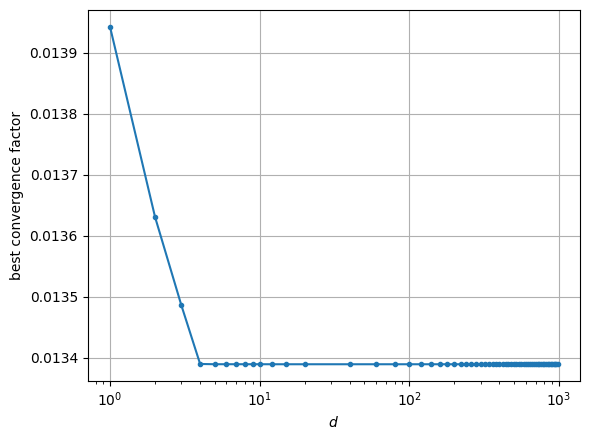

In [68]:
#Figure 4.2

saved_n2m2_d1_1000_exact_plus_small_range = torch.load(
    "models/n2m2_d1_1000_exact_plus_small_range.pt",
    map_location="cpu",
    weights_only=False
)

# Falls die Datei eine Liste enthält
d_values = [1,2,3,4,5,6,7,8,9,10,12,15] + list(range(20, 1000, 20))


d_plot = []
gamma_plot = []

for result in saved_n2m2_d1_1000_exact_plus_small_range:
    d_plot.append(result["d"])
    gamma_plot.append(float(result["best_gamma"]))

# Sicherheitshalber nach d sortieren
pairs = sorted(zip(d_plot, gamma_plot))
d_plot, gamma_plot = zip(*pairs)

plt.figure(figsize=(6, 4.5))
plt.plot(d_plot, gamma_plot, marker="o", markersize=3)

plt.xscale("log")
plt.xlabel(r"$d$")
plt.ylabel(r"best convergence factor")
plt.grid(True)
plt.tight_layout()

plt.savefig("best_gamma_vs_d.png", dpi=300, bbox_inches="tight")

plt.savefig(
    "/content/Konvergenzfaktoren: supremum OCP_c_1_1000_exact plus small.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()



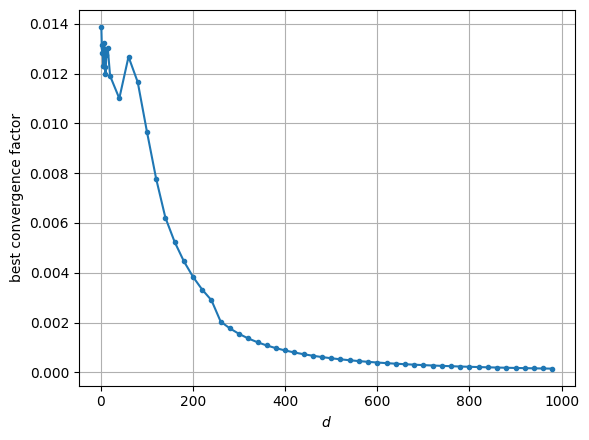

In [69]:
#Figure 4.1

saved_A_n2m2_d1_1000 = torch.load(
    "models/A_stable_n2m2_d1_1000 (2).pt",
    map_location="cpu",
    weights_only=False
)

# Falls die Datei eine Liste enthält
d_values = [1,2,3,4,5,6,7,8,9,10,12,15] + list(range(20, 1000, 20))


d_plot = []
gamma_plot = []

for result in saved_A_n2m2_d1_1000:
    d_plot.append(result["d"])
    gamma_plot.append(float(result["best_gamma"]))

# Sicherheitshalber nach d sortieren
pairs = sorted(zip(d_plot, gamma_plot))
d_plot, gamma_plot = zip(*pairs)

plt.figure(figsize=(6, 4.5))
plt.plot(d_plot, gamma_plot, marker="o", markersize=3)

plt.xlabel(r"$d$")
plt.ylabel(r"best convergence factor")
plt.grid(True)
plt.tight_layout()

plt.savefig("best_gamma_vs_d.png", dpi=300, bbox_inches="tight")
plt.show()



a = [ 1.         -0.20785606  0.00480755]
b = [1.         0.79214394 0.38527623]
best_gamma = 0.013869518414139748
a = [ 1.         -0.20150065  0.00455102]
b = [1.         0.79849935 0.38437217]
best_gamma = 0.011997283436357975
a = [ 1.         -0.19183761  0.00377487]
b = [1.         0.80816239 0.39486104]
best_gamma = 0.009667057543992996
a = [ 1.00000000e+00 -4.93318439e-02  2.26420816e-04]
b = [1.         0.95066816 0.40011814]
best_gamma = 0.0005665638018399477
a = [ 1.00000000e+00 -2.75507569e-02  7.08949447e-05]
b = [1.         0.97244924 0.40011814]
best_gamma = 0.00017721488256938756


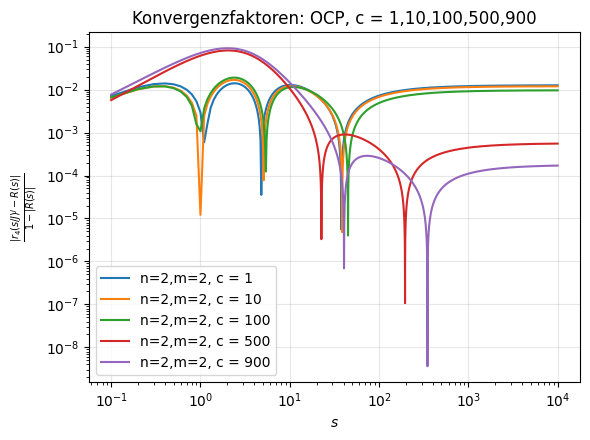

In [70]:
#Figure 4.1

import numpy as np
import matplotlib.pyplot as plt
import torch

saved_A_1 = torch.load(
    "models/ocp_result_1_A_stable (1).pt",
    map_location="cpu",
    weights_only=False
)

# Falls die Datei eine Liste enthält
if isinstance(saved_A_1, list):
    result = saved_A_1[0]
else:
    result = saved_A_1

a_opt_A_1= result["a"].detach().cpu().numpy().astype(np.float64)
b_opt_A_1= result["b"].detach().cpu().numpy().astype(np.float64)

print("a =", a_opt_A_1)
print("b =", b_opt_A_1)
print("best_gamma =", result["best_gamma"])

####

saved_A_10 = torch.load(
    "models/ocp_result_10_A_stable.pt",
    map_location="cpu",
    weights_only=False
)

# Falls die Datei eine Liste enthält
if isinstance(saved_A_10, list):
    result = saved_A_10[0]
else:
    result = saved_A_10

a_opt_A_10= result["a"].detach().cpu().numpy().astype(np.float64)
b_opt_A_10= result["b"].detach().cpu().numpy().astype(np.float64)

print("a =", a_opt_A_10)
print("b =", b_opt_A_10)
print("best_gamma =", result["best_gamma"])

##########

saved_A_100 = torch.load(
    "models/ocp_result_100_A_stable.pt",
    map_location="cpu",
    weights_only=False
)

# Falls die Datei eine Liste enthält
if isinstance(saved_A_100, list):
    result = saved_A_100[0]
else:
    result = saved_A_100

a_opt_A_100= result["a"].detach().cpu().numpy().astype(np.float64)
b_opt_A_100= result["b"].detach().cpu().numpy().astype(np.float64)

print("a =", a_opt_A_100)
print("b =", b_opt_A_100)
print("best_gamma =", result["best_gamma"])


###########


saved_A_500 = torch.load(
    "models/ocp_result_500_A_stable.pt",
    map_location="cpu",
    weights_only=False
)

# Falls die Datei eine Liste enthält
if isinstance(saved_A_500, list):
    result = saved_A_500[0]
else:
    result = saved_A_500

a_opt_A_500= result["a"].detach().cpu().numpy().astype(np.float64)
b_opt_A_500= result["b"].detach().cpu().numpy().astype(np.float64)

print("a =", a_opt_A_500)
print("b =", b_opt_A_500)
print("best_gamma =", result["best_gamma"])


#############

saved_A_900 = torch.load(
    "models/ocp_result_900_A_stable.pt",
    map_location="cpu",
    weights_only=False
)

# Falls die Datei eine Liste enthält
if isinstance(saved_A_900, list):
    result = saved_A_900[0]
else:
    result = saved_A_900

a_opt_A_900= result["a"].detach().cpu().numpy().astype(np.float64)
b_opt_A_900= result["b"].detach().cpu().numpy().astype(np.float64)

print("a =", a_opt_A_900)
print("b =", b_opt_A_900)
print("best_gamma =", result["best_gamma"])




################# Stability functions ################################
def R_opt_A_1(x):
    numerator = np.polynomial.polynomial.polyval(x, a_opt_A_1)
    denominator = np.polynomial.polynomial.polyval(x, b_opt_A_1)
    return numerator / denominator
def R_opt_A_10(x):
    numerator = np.polynomial.polynomial.polyval(x, a_opt_A_10)
    denominator = np.polynomial.polynomial.polyval(x, b_opt_A_10)
    return numerator / denominator
def R_opt_A_100(x):
    numerator = np.polynomial.polynomial.polyval(x, a_opt_A_100)
    denominator = np.polynomial.polynomial.polyval(x, b_opt_A_100)
    return numerator / denominator
def R_opt_A_500(x):
    numerator = np.polynomial.polynomial.polyval(x, a_opt_A_500)
    denominator = np.polynomial.polynomial.polyval(x, b_opt_A_500)
    return numerator / denominator
def R_opt_A_900(x):
    numerator = np.polynomial.polynomial.polyval(x, a_opt_A_900)
    denominator = np.polynomial.polynomial.polyval(x, b_opt_A_900)
    return numerator / denominator



def r4(x):
    return (12*x**2 - 120*x + 360) / (
        x**4 + 12*x**3 + 72*x**2 + 240*x + 360
    )

######################################################################

s = np.linspace(0.1, 10000, 100000)

J=20

fine_value = r4(s / J)**J

R_A_1 = R_opt_A_1(s)
R_A_10 = R_opt_A_10(s)
R_A_100 = R_opt_A_100(s)
R_A_500 = R_opt_A_500(s)
R_A_900 = R_opt_A_900(s)


######################################################################

kappa_A_1= (
    np.abs(fine_value - R_A_1)
    / (1.0 - np.abs(R_A_1))
)
kappa_A_10= (
    np.abs(fine_value - R_A_10)
    / (1.0 - np.abs(R_A_10))
)
kappa_A_100= (
    np.abs(fine_value - R_A_100)
    / (1.0 - np.abs(R_A_100))
)
kappa_A_500= (
    np.abs(fine_value - R_A_500)
    / (1.0 - np.abs(R_A_500))
)
kappa_A_900= (
    np.abs(fine_value - R_A_900)
    / (1.0 - np.abs(R_A_900))
)




plt.figure(figsize=(6, 4.5))

plt.plot(
    s,
    kappa_A_1,
    label="n=2,m=2, c = 1"
)
plt.plot(
    s,
    kappa_A_10,
    label="n=2,m=2, c = 10"
)
plt.plot(
    s,
    kappa_A_100,
    label="n=2,m=2, c = 100"
)
plt.plot(
    s,
    kappa_A_500,
    label="n=2,m=2, c = 500"
)
plt.plot(
    s,
    kappa_A_900,
    label="n=2,m=2, c = 900"
)



plt.yscale("log")
plt.xscale("log")
plt.xlabel(r"$s$")
plt.ylabel(
    r"$\frac{|r_4(s/J)^J-R(s)|}{1-|R(s)|}$"
)

plt.title(
    "Konvergenzfaktoren: OCP, c = 1,10,100,500,900"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/Konvergenzfaktoren: OCP, c = 1,10,100,500,900.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import solve
from numpy.polynomial.legendre import leggauss
import torch
from scipy.linalg import eigh
from scipy.linalg import solve

!git clone https://github.com/Philipp3011/Parareal-OCP-Convergence-tests-bachelor-thesis.git
%cd Parareal-OCP-Convergence-tests-bachelor-thesis

from parareal_grundfunktionen import *
from propagators import FP, BE, SDIRK22


def parareal_error_for_plot(CP_method, FP_method, J, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine=None, K=25):

    delta_T = (t_end - t_0) / int(N / J)

    U_fine = U_fine_full[::J]

    P_i_sum_CP, R_T_A_h_CP = prepare_CP(delta_T, A_h, CP_method["P"], CP_method["R"])

    if RHS_values_fine is None:
        RHS_values_CP = None
    else:
        RHS_values_CP = prepare_rhs(CP_method["C"], f, mass, delta_T, T_intervall, M, OMEGA)

    _, error = parareal_fehlervergleich(RHS_values_CP, RHS_values_fine, R_T_A_h_CP, R_T_A_h_fine,
                                        P_i_sum_CP, P_i_sum_fine, CP, T_intervall, U_fine, M, N, J, u_0, f,
                                        CP_method["R"], FP_method["R"], CP_method["P"], FP_method["P"],
                                        CP_method["C"], FP_method["C"], K, A_h, stiff, mass, v_h)
    return error


Cloning into 'Parareal-OCP-Convergence-tests-bachelor-thesis'...
remote: Enumerating objects: 221, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 221 (delta 15), reused 2 (delta 2), pack-reused 196 (from 2)
Receiving objects: 100% (221/221), 360.03 KiB | 2.97 MiB/s, done.
Resolving deltas: 100% (132/132), done.
/content/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis/Parareal-OCP-Convergence-tests-bachelor-thesis

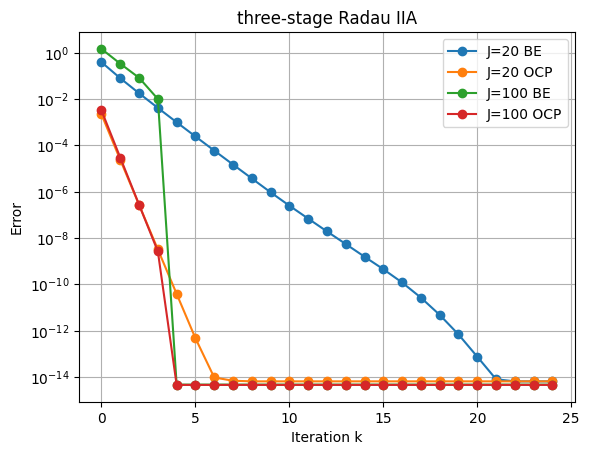

In [72]:
# Example Section 3.4 "first numerical illustration", 3-stage RADAU IIA implementation,
# The call for 4-stage LOBATTO IIIC is in the example implementations.

def u0_a(x):
    return (x**10) * ((x-np.pi)**10) * ((np.pi/2)**(-10))

def f_a(x, t):
    return 0

M = 1000
OMEGA = (0, np.pi)
T_intervall = (0,1)
N = 500
u_0 = u0_a
f = f_a

t_0, t_end = T_intervall

# Spatial discretization
tri = mesh(M, OMEGA)
inner_tri = tri[1:-1]

stiff, mass = matrix(M, OMEGA, inner_tri)
A_h = solve(mass, stiff)

v_h = np.asarray(u_0(inner_tri), dtype=np.float64)

#fine propagator and precalculated values
fp = FP["RadauIIA3"]

delta_t = (t_end - t_0) / N

P_i_sum_fine, R_T_A_h_fine = prepare_CP(delta_t, A_h, fp["P"], fp["R"])

# f = 0, therefore RHS_values = None
RHS_values_fine = prepare_rhs(fp["C"], f, mass, delta_t, T_intervall, M, OMEGA)
U_fine_full = calculate_U(RHS_values_fine, R_T_A_h_fine, P_i_sum_fine, f, M, N, OMEGA, mesh, u_0, T_intervall, fp["R"], fp["P"], fp["C"], A_h, mass, v_h)

OCP_J20 = load_OCP("models/n2m2_exact_eig_RADAUIIA3_J20.pt")
OCP_J100 = load_OCP("models/n2m2_exact_eig_RADAUIIA3_J100.pt")


J = 20
K = int(N /J)
delta_T = (t_end - t_0) / int(N /J)

error_BE_J20 = parareal_error_for_plot(BE, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_OCP_J20 = parareal_error_for_plot(OCP_J20, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_BE_J100 = parareal_error_for_plot(BE, fp, 100, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_OCP_J100 = parareal_error_for_plot(OCP_J100, fp, 100, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

#creating the plot
plt.plot(error_BE_J20, marker="o", label="J=20 BE")
plt.plot(error_OCP_J20, marker="o", label="J=20 OCP")
plt.plot(error_BE_J100, marker="o", label="J=100 BE")
plt.plot(error_OCP_J100, marker="o", label="J=100 OCP")

plt.yscale("log")
plt.xlabel("Iteration k")
plt.ylabel("Error")
plt.title("three-stage Radau IIA")
plt.grid(True)
plt.legend()
plt.show()



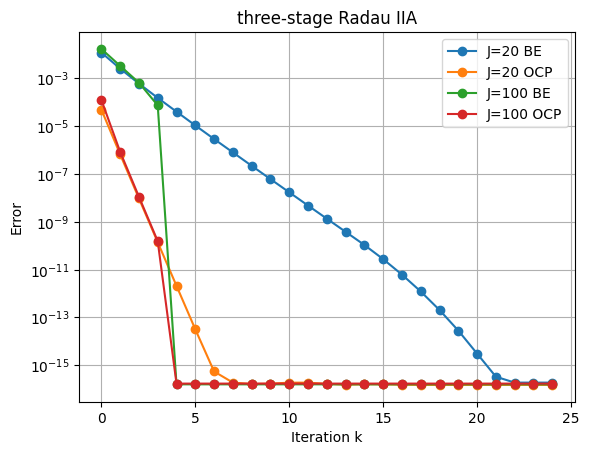

In [73]:
#Exmaple 5.1 (b) 3-stage RADAU IIIA,

# Example Section 3.4 "first numerical illustration", 3-stage RADAU IIA implementation,
# The call for 4-stage LOBATTO IIIC is in the example implementations.

def u0_b(x):
    return np.where(
        (x > 0) & (x < np.pi/2),
        1.0,
        0.0
    )

def f_b(x, t):
    return np.cos(t) * np.sin(x)

M = 1000
OMEGA = (0, np.pi)
T_intervall = (0,1)
N = 500
u_0 = u0_b
f = f_b

t_0, t_end = T_intervall

# Spatial discretization
tri = mesh(M, OMEGA)
inner_tri = tri[1:-1]

stiff, mass = matrix(M, OMEGA, inner_tri)
A_h = solve(mass, stiff)

v_h = np.asarray(u_0(inner_tri), dtype=np.float64)

#fine propagator and precalculated values
fp = FP["RadauIIA3"]

delta_t = (t_end - t_0) / N

P_i_sum_fine, R_T_A_h_fine = prepare_CP(delta_t, A_h, fp["P"], fp["R"])

# f = 0, therefore RHS_values = None
RHS_values_fine = prepare_rhs(fp["C"], f, mass, delta_t, T_intervall, M, OMEGA)
U_fine_full = calculate_U(RHS_values_fine, R_T_A_h_fine, P_i_sum_fine, f, M, N, OMEGA, mesh, u_0, T_intervall, fp["R"], fp["P"], fp["C"], A_h, mass, v_h)

OCP_J20 = load_OCP("models/n1m2_001_100_RADAUIIA3_J20.pt")
OCP_J100 = load_OCP("models/n1m2_001_100_RADAUIIA3_J100.pt")


J = 20
K = int(N /J)
delta_T = (t_end - t_0) / int(N /J)

error_BE_J20 = parareal_error_for_plot(BE, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_OCP_J20 = parareal_error_for_plot(OCP_J20, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_BE_J100 = parareal_error_for_plot(BE, fp, 100, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_OCP_J100 = parareal_error_for_plot(OCP_J100, fp, 100, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

#creating the plot
plt.plot(error_BE_J20, marker="o", label="J=20 BE")
plt.plot(error_OCP_J20, marker="o", label="J=20 OCP")
plt.plot(error_BE_J100, marker="o", label="J=100 BE")
plt.plot(error_OCP_J100, marker="o", label="J=100 OCP")

plt.yscale("log")
plt.xlabel("Iteration k")
plt.ylabel("Error")
plt.title("three-stage Radau IIA")
plt.grid(True)
plt.legend()
plt.show()



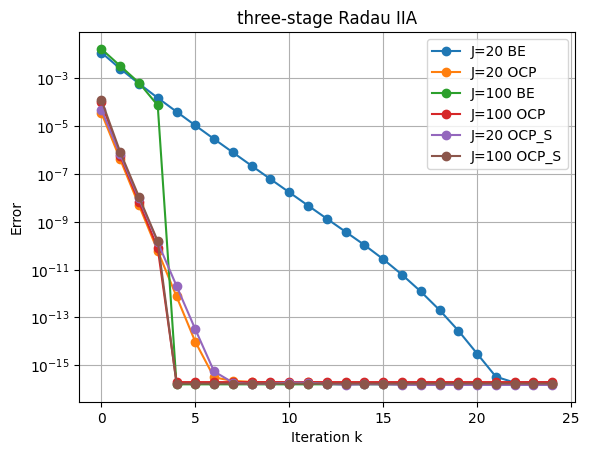

In [74]:
#Exmaple 5.1 (b) 3-stage RADAU IIA, PLOT: 5.1 BOTTOM RIGHT

def u0_b(x):
    return np.where(
        (x > 0) & (x < np.pi/2),
        1.0,
        0.0
    )

def f_b(x, t):
    return np.cos(t) * np.sin(x)

M = 1000
OMEGA = (0, np.pi)
T_intervall = (0,1)
N = 500
u_0 = u0_b
f = f_b

t_0, t_end = T_intervall

# Spatial discretization
tri = mesh(M, OMEGA)
inner_tri = tri[1:-1]

stiff, mass = matrix(M, OMEGA, inner_tri)
A_h = solve(mass, stiff)

v_h = np.asarray(u_0(inner_tri), dtype=np.float64)

#fine propagator and precalculated values
fp = FP["RadauIIA3"]

delta_t = (t_end - t_0) / N

P_i_sum_fine, R_T_A_h_fine = prepare_CP(delta_t, A_h, fp["P"], fp["R"])

# f = 0, therefore RHS_values = None
RHS_values_fine = prepare_rhs(fp["C"], f, mass, delta_t, T_intervall, M, OMEGA)
U_fine_full = calculate_U(RHS_values_fine, R_T_A_h_fine, P_i_sum_fine, f, M, N, OMEGA, mesh, u_0, T_intervall, fp["R"], fp["P"], fp["C"], A_h, mass, v_h)

OCP_S_J20 = load_OCP("models/n1m2_001_100_RADAUIIA3_J20.pt")
OCP_S_J100 = load_OCP("models/n1m2_001_100_RADAUIIA3_J100.pt")

OCP_J20 = load_OCP("models/n2m2_exact_eig_RADAUIIA3_J20.pt")
OCP_J100 = load_OCP("models/n2m2_exact_eig_RADAUIIA3_J100.pt")

J = 20
K = int(N /J)
delta_T = (t_end - t_0) / int(N /J)

error_BE_J20 = parareal_error_for_plot(BE, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_OCP_J20 = parareal_error_for_plot(OCP_J20, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_OCP_S_J20 = parareal_error_for_plot(OCP_S_J20, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_BE_J100 = parareal_error_for_plot(BE, fp, 100, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_OCP_J100 = parareal_error_for_plot(OCP_J100, fp, 100, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_OCP_S_J100 = parareal_error_for_plot(OCP_S_J100, fp, 100, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)


#creating the plot
plt.plot(error_BE_J20, marker="o", label="J=20 BE")
plt.plot(error_OCP_J20, marker="o", label="J=20 OCP")
plt.plot(error_BE_J100, marker="o", label="J=100 BE")
plt.plot(error_OCP_J100, marker="o", label="J=100 OCP")
plt.plot(error_OCP_S_J20, marker="o", label="J=20 OCP_S")
plt.plot(error_OCP_S_J100, marker="o", label="J=100 OCP_S")


plt.yscale("log")
plt.xlabel("Iteration k")
plt.ylabel("Error")
plt.title("three-stage Radau IIA")
plt.grid(True)
plt.legend()
plt.show()



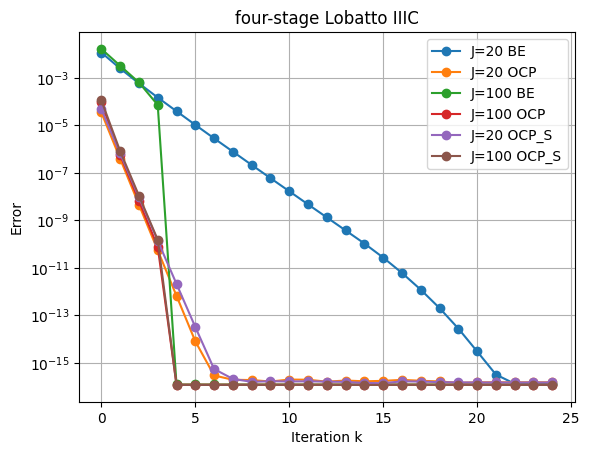

In [75]:
#Exmaple 5.1 (b) 4-stage LOBATTO IIIC, PLOT: FIGURE 5.1 bottom left

def u0_b(x):
    return np.where(
        (x > 0) & (x < np.pi/2),
        1.0,
        0.0
    )

def f_b(x, t):
    return np.cos(t) * np.sin(x)

M = 1000
OMEGA = (0, np.pi)
T_intervall = (0,1)
N = 500
u_0 = u0_b
f = f_b

t_0, t_end = T_intervall

# Spatial discretization
tri = mesh(M, OMEGA)
inner_tri = tri[1:-1]

stiff, mass = matrix(M, OMEGA, inner_tri)
A_h = solve(mass, stiff)

v_h = np.asarray(u_0(inner_tri), dtype=np.float64)

#fine propagator and precalculated values
fp = FP["LobattoIIIC4"]

delta_t = (t_end - t_0) / N

P_i_sum_fine, R_T_A_h_fine = prepare_CP(delta_t, A_h, fp["P"], fp["R"])

# f = 0, therefore RHS_values = None
RHS_values_fine = prepare_rhs(fp["C"], f, mass, delta_t, T_intervall, M, OMEGA)
U_fine_full = calculate_U(RHS_values_fine, R_T_A_h_fine, P_i_sum_fine, f, M, N, OMEGA, mesh, u_0, T_intervall, fp["R"], fp["P"], fp["C"], A_h, mass, v_h)

OCP_S_J20 = load_OCP("models/n1m2_001_100_LOBATTOIIIC4_J20.pt")
OCP_S_J100 = load_OCP("models/n1m2_001_100_LOBATTOIIIC4_J100.pt")

OCP_J20 = load_OCP("models/n2m2_exact_eig_LOBATTOIIIC4_J20.pt")
OCP_J100 = load_OCP("models/n2m2_exact_eig_LOBATTOIIIC4_J100.pt")

J = 20
K = int(N /J)
delta_T = (t_end - t_0) / int(N /J)

error_BE_J20 = parareal_error_for_plot(BE, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_OCP_J20 = parareal_error_for_plot(OCP_J20, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_OCP_S_J20 = parareal_error_for_plot(OCP_S_J20, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_BE_J100 = parareal_error_for_plot(BE, fp, 100, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_OCP_J100 = parareal_error_for_plot(OCP_J20, fp, 100, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_OCP_S_J100 = parareal_error_for_plot(OCP_S_J100, fp, 100, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)


#creating the plot
plt.plot(error_BE_J20, marker="o", label="J=20 BE")
plt.plot(error_OCP_J20, marker="o", label="J=20 OCP")
plt.plot(error_BE_J100, marker="o", label="J=100 BE")
plt.plot(error_OCP_J100, marker="o", label="J=100 OCP")
plt.plot(error_OCP_S_J20, marker="o", label="J=20 OCP_S")
plt.plot(error_OCP_S_J100, marker="o", label="J=100 OCP_S")

plt.yscale("log")
plt.xlabel("Iteration k")
plt.ylabel("Error")
plt.title("four-stage Lobatto IIIC")
plt.grid(True)
plt.legend()
plt.show()



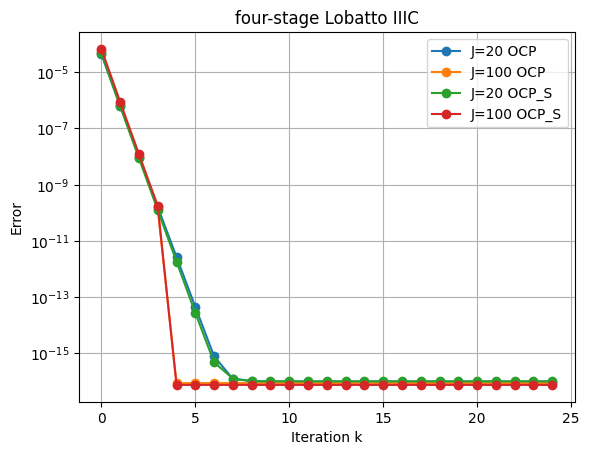

In [76]:
#Exmaple 5.3 a = 100 4-stage LOBATTO IIIC, PLOT: FIGURE 5.2


def a(x):
    if x < np.pi/2:
        return 1.0
    else:
        return 10000.0

def u0_2(x):
    return np.where((x > np.pi/4) & (x < 3*np.pi/4), 1.0, 0.0)


def f_2(x, t):
    return 0.0

M= 1000
OMEGA = (0, np.pi)
T_intervall = (0,1)
N = 500
u_0 = u0_2
f = f_2

t_0, t_end = T_intervall

# Spatial discretization
tri = mesh(M, OMEGA)
inner_tri = tri[1:-1]

stiff, mass = matrix(M, OMEGA, inner_tri)
A_h = solve(mass, stiff)

v_h = np.asarray(u_0(inner_tri), dtype=np.float64)

#fine propagator and precalculated values
fp = FP["LobattoIIIC4"]

delta_t = (t_end - t_0) / N

P_i_sum_fine, R_T_A_h_fine = prepare_CP(delta_t, A_h, fp["P"], fp["R"])

# f = 0, therefore RHS_values = None
RHS_values_fine = prepare_rhs(fp["C"], f, mass, delta_t, T_intervall, M, OMEGA)
U_fine_full = calculate_U(RHS_values_fine, R_T_A_h_fine, P_i_sum_fine, f, M, N, OMEGA, mesh, u_0, T_intervall, fp["R"], fp["P"], fp["C"], A_h, mass, v_h)

OCP_S_J20 = load_OCP("models/n1m2_001_100_LOBATTOIIIC4_J20.pt")
OCP_S_J100 = load_OCP("models/n1m2_001_100_LOBATTOIIIC4_J100.pt")

OCP_J20 = load_OCP("models/n1m2_exact_eig_LOBATTOIIIC4_J20_a100.pt")
OCP_J100 = load_OCP("models/n1m2_exact_eig_LOBATTOIIIC4_J100_a100.pt")

J = 20
K = int(N /J)
delta_T = (t_end - t_0) / int(N /J)


error_OCP_J20 = parareal_error_for_plot(OCP_J20, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_OCP_S_J20 = parareal_error_for_plot(OCP_S_J20, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_OCP_J100 = parareal_error_for_plot(OCP_J20, fp, 100, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_OCP_S_J100 = parareal_error_for_plot(OCP_S_J100, fp, 100, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)


#creating the plot
plt.plot(error_OCP_J20, marker="o", label="J=20 OCP")
plt.plot(error_OCP_J100, marker="o", label="J=100 OCP")
plt.plot(error_OCP_S_J20, marker="o", label="J=20 OCP_S")
plt.plot(error_OCP_S_J100, marker="o", label="J=100 OCP_S")

plt.yscale("log")
plt.xlabel("Iteration k")
plt.ylabel("Error")
plt.title("four-stage Lobatto IIIC")
plt.grid(True)
plt.legend()
plt.show()



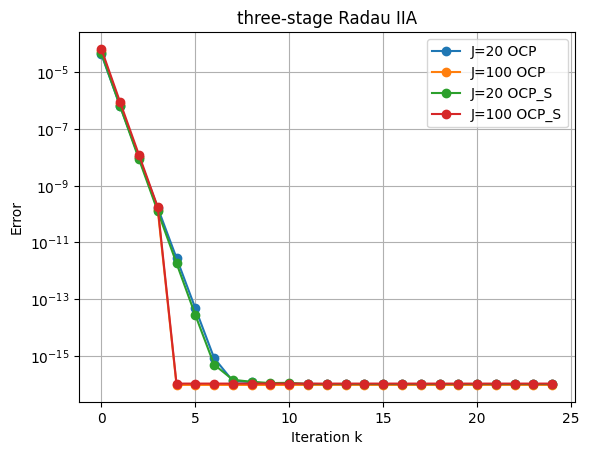

In [77]:
#Exmaple 5.3 a = 100 3-stage RADAU IIA, PLOT: FIGURE 5.2


def a(x):
    if x < np.pi/2:
        return 1.0
    else:
        return 10000.0

def u0_2(x):
    return np.where((x > np.pi/4) & (x < 3*np.pi/4), 1.0, 0.0)


def f_2(x, t):
    return 0.0

M= 1000
OMEGA = (0, np.pi)
T_intervall = (0,1)
N = 500
u_0 = u0_2
f = f_2

t_0, t_end = T_intervall

# Spatial discretization
tri = mesh(M, OMEGA)
inner_tri = tri[1:-1]

stiff, mass = matrix(M, OMEGA, inner_tri)
A_h = solve(mass, stiff)

v_h = np.asarray(u_0(inner_tri), dtype=np.float64)

#fine propagator and precalculated values
fp = FP["RadauIIA3"]

delta_t = (t_end - t_0) / N

P_i_sum_fine, R_T_A_h_fine = prepare_CP(delta_t, A_h, fp["P"], fp["R"])

# f = 0, therefore RHS_values = None
RHS_values_fine = prepare_rhs(fp["C"], f, mass, delta_t, T_intervall, M, OMEGA)
U_fine_full = calculate_U(RHS_values_fine, R_T_A_h_fine, P_i_sum_fine, f, M, N, OMEGA, mesh, u_0, T_intervall, fp["R"], fp["P"], fp["C"], A_h, mass, v_h)

OCP_S_J20 = load_OCP("models/n1m2_001_100_RADAUIIA3_J20.pt")
OCP_S_J100 = load_OCP("models/n1m2_001_100_RADAUIIA3_J100.pt")

OCP_J20 = load_OCP("models/n1m2_exact_eig_RADAUIIA3_J20_a100.pt")
OCP_J100 = load_OCP("models/n1m2_exact_eig_RADAUIIA3_J100_a100.pt")

J = 20
K = int(N /J)
delta_T = (t_end - t_0) / int(N /J)


error_OCP_J20 = parareal_error_for_plot(OCP_J20, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_OCP_S_J20 = parareal_error_for_plot(OCP_S_J20, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_OCP_J100 = parareal_error_for_plot(OCP_J20, fp, 100, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)

error_OCP_S_J100 = parareal_error_for_plot(OCP_S_J100, fp, 100, U_fine_full, R_T_A_h_fine, P_i_sum_fine, RHS_values_fine, K=25)


#creating the plot
plt.plot(error_OCP_J20, marker="o", label="J=20 OCP")
plt.plot(error_OCP_J100, marker="o", label="J=100 OCP")
plt.plot(error_OCP_S_J20, marker="o", label="J=20 OCP_S")
plt.plot(error_OCP_S_J100, marker="o", label="J=100 OCP_S")

plt.yscale("log")
plt.xlabel("Iteration k")
plt.ylabel("Error")
plt.title("three-stage Radau IIA")
plt.grid(True)
plt.legend()
plt.show()



In [78]:
def parareal_error_scalar_for_plot(CP_method, FP_method, J, U_fine_full, R_T_A_h_fine, P_i_sum_fine, K=25):

    delta_T = J * ((t_end - t_0) / N)

    U_fine = U_fine_full[::J]

    if "R_scalar" in CP_method:
        P_i_sum_CP, R_T_A_h_CP = prepare_R_spectral(delta_T, CP_method["R_scalar"], eigenvalues, eigenvectors, eigenvectors_inverse)

    else:
        P_i_sum_CP, R_T_A_h_CP = prepare_CP(delta_T, A_h, CP_method["P"], CP_method["R"])


    _, error = parareal_fehlervergleich(None, None, R_T_A_h_CP, R_T_A_h_fine,
                                        P_i_sum_CP, P_i_sum_fine, CP, T_intervall, U_fine, M, N, J, u_0, f,
                                        CP_method["R"], FP_method["R"], CP_method["P"], FP_method["P"],
                                        CP_method["C"], FP_method["C"], K, A_h, stiff, mass, v_h)

    return error

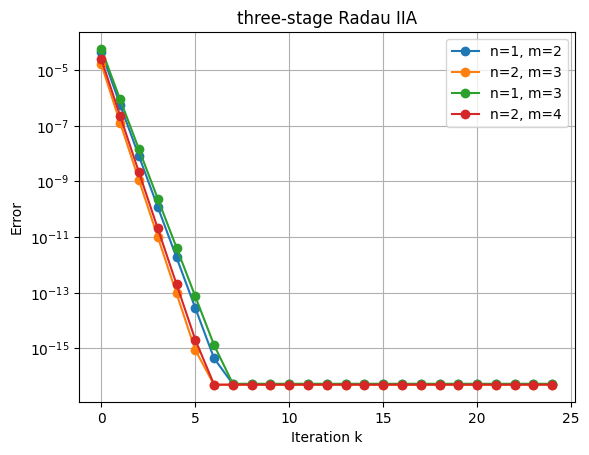

In [79]:
#Example 5.3 a=10000, figure 5.4 three-stage RADAU IIA

def a(x):
    if x < np.pi/2:
        return 1.0
    else:
        return 10000.0

def u0_2(x):
    return np.where((x > np.pi/4) & (x < 3*np.pi/4), 1.0, 0.0)


def f_2(x, t):
    return 0.0

M= 1000
OMEGA = (0, np.pi)
T_intervall = (0,1)
N = 500
u_0 = u0_2
f = f_2

t_0, t_end = T_intervall

# Spatial discretization

tri = mesh(M, OMEGA)
inner_tri = tri[1:-1]

_, mass = matrix(M, OMEGA, inner_tri)
stiff = dsicrete_operator_div_a_grad_u(
    M, OMEGA, inner_tri, a, quad_order=3
)

A_h = solve(mass, stiff)

v_h = np.asarray(u_0(inner_tri), dtype=np.float64)

# Eigenvalue decomposition used for the spectral evaluation
eigenvalues, eigenvectors = eigh(stiff, mass)
eigenvectors_inverse = eigenvectors.T @ mass


# Fine propagator and precalculated values
fp = FP["RadauIIA3"]

delta_t = (t_end - t_0) / N

P_i_sum_fine, R_T_A_h_fine = prepare_R_spectral(delta_t, fp["R_scalar"], eigenvalues, eigenvectors, eigenvectors_inverse)


U_fine_full = calculate_U(None, R_T_A_h_fine, P_i_sum_fine, f, M, N, OMEGA,
                          mesh, u_0, T_intervall, fp["R"], fp["P"], fp["C"],
                          A_h, mass, v_h)


OCP_J20_n1m2 = load_OCP("models/n1m2_001_100_RADAUIIA3_J20.pt")
OCP_J20_n2m3 = load_OCP("models/n2m3_001_100_RADAUIIA3_J20.pt")
OCP_J20_n1m3 = load_OCP("models/n1m3_001_100_RADAUIIA3_J20.pt")
OCP_J20_n2m4 = load_OCP("models/n2m4_001_100_RADAUIIA3_J20.pt")

error_OCP_n1m2 = parareal_error_scalar_for_plot(OCP_J20_n1m2, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, K=25)

error_OCP_n2m3 = parareal_error_scalar_for_plot(OCP_J20_n2m3, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, K=25)

error_OCP_n1m3 = parareal_error_scalar_for_plot(OCP_J20_n1m3, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, K=25)

error_OCP_n2m4 = parareal_error_scalar_for_plot(OCP_J20_n2m4, fp, 20, U_fine_full, R_T_A_h_fine, P_i_sum_fine, K=25)


plt.plot(error_OCP_n1m2, marker="o", label="n=1, m=2")
plt.plot(error_OCP_n2m3, marker="o", label="n=2, m=3")
plt.plot(error_OCP_n1m3, marker="o", label="n=1, m=3")
plt.plot(error_OCP_n2m4, marker="o", label="n=2, m=4")

plt.yscale("log")
plt.xlabel("Iteration k")
plt.ylabel("Error")
plt.title("three-stage Radau IIA")
plt.grid(True)
plt.legend()
plt.show()